In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = ('/content/drive/MyDrive/Colab Notebooks/BI')

Mounted at /content/drive


##Thư viện

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

##Đọc file

In [ ]:
df_translate = pd.read_excel(folder + '/Data/Order Review.xlsx', sheet_name = 'Translate review message')

##Xử lí data + khởi tạo Sentiment Analysis

In [ ]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
df_translate.columns = df_translate.columns.str.strip()
df_translate = df_translate.dropna(subset=['review_comment_message_english'])
sid = SentimentIntensityAnalyzer()

##Sentiment analysis function

In [ ]:
def analyze_sentiment(text):
    if not isinstance(text, str):
        return pd.Series({'compound_score': 0.0, 'sentiment_label': 'Neutral'})

    # Lấy điểm số cảm xúc (compound score dao động từ -1.0 đến 1.0)
    scores = sid.polarity_scores(text)
    compound = scores['compound']

    # Phân loại dựa trên điểm số
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'

    return pd.Series({'compound_score': compound, 'sentiment_label': label})

##Kết quả

In [ ]:
sentiment_results = df_translate['review_comment_message_english'].apply(analyze_sentiment)
df_final = pd.concat([df_translate, sentiment_results], axis=1)

In [ ]:
print("KẾT QUẢ")
print(df_final[['review_comment_message_english', 'compound_score', 'sentiment_label']].head(10))

KẾT QUẢ
                      review_comment_message_english  compound_score  \
0   MY PURCHASE ARRIVED PERFECTLY, DELIVERY WAS V...          0.6369   
1   The digital scale is beautiful, but it does n...          0.4102   
2   The cover and film met expectations. Both pro...          0.5095   
3   - the purchase was made on 30/01 - the invoic...         -0.7109   
4   The product was delivered ahead of schedule, ...          0.3612   
5   Delivery was fast and arrived very well packa...          0.3384   
6   The store advertises one product and delivers...          0.0000   
7                                 the store is great          0.6249   
8   The store posted the product and the mail too...          0.0000   
9   The store sold and delivered everything ok, b...         -0.1901   

  sentiment_label  
0        Positive  
1        Positive  
2        Positive  
3        Negative  
4        Positive  
5        Positive  
6         Neutral  
7        Positive  
8         Neutral  

In [ ]:
sentiment_counts = df_final['sentiment_label'].value_counts()

total_positive = sentiment_counts.get('Positive', 0)
total_negative = sentiment_counts.get('Negative', 0)
total_neutral = sentiment_counts.get('Neutral', 0)
total_reviews = len(df_final)

print(f"Tổng số đánh giá đã xử lý: {total_reviews}")
print(f"Tích cực (Positive) : {total_positive} ({total_positive/total_reviews*100:.1f}%)")
print(f"Tiêu cực (Negative) : {total_negative} ({total_negative/total_reviews*100:.1f}%)")
print(f"Trung tính (Neutral): {total_neutral} ({total_neutral/total_reviews*100:.1f}%)")

Tổng số đánh giá đã xử lý: 40920
Tích cực (Positive) : 24602 (60.1%)
Tiêu cực (Negative) : 6348 (15.5%)
Trung tính (Neutral): 9970 (24.4%)


/tmp/ipykernel_19835/2500357353.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors, ax=ax[0])


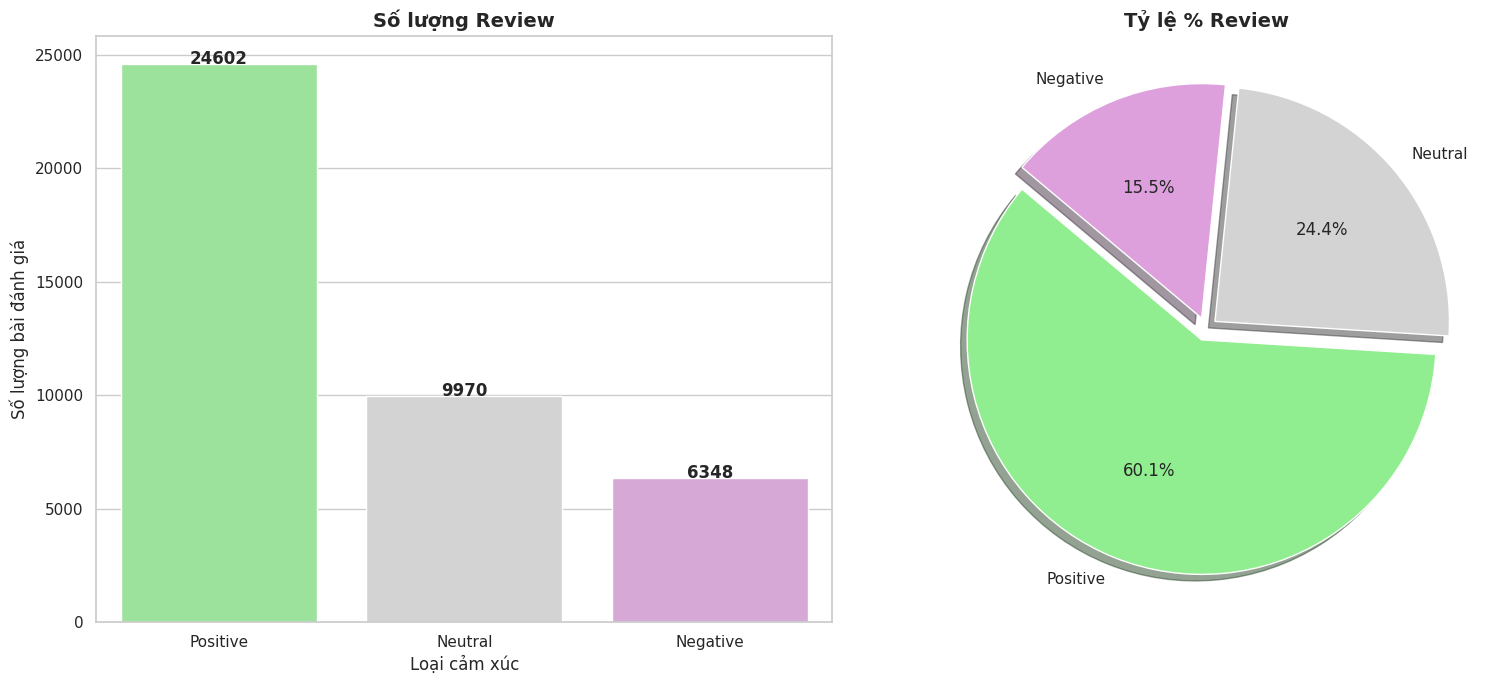

In [ ]:
sns.set(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# BIỂU ĐỒ 1: Bar plot
colors = ['lightgreen', 'lightgrey', 'plum']
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors, ax=ax[0])
ax[0].set_title('Số lượng Review', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Loại cảm xúc')
ax[0].set_ylabel('Số lượng bài đánh giá')

for i, v in enumerate(sentiment_counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# BIỂU ĐỒ 2: Pie plot
ax[1].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0.05, 0.05),
    shadow=True
)
ax[1].set_title('Tỷ lệ % Review', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

##Xuất file

In [ ]:
output_file = folder + '/Data/Sentiment_Analysis_Results.csv'
df_final.to_csv(output_file, index=False)
print(f"\nĐã lưu kết quả thành công vào file: {output_file}")


Đã lưu kết quả thành công vào file: /content/drive/MyDrive/Colab Notebooks/BI/Data/Sentiment_Analysis_Results.csv


##WordCloud

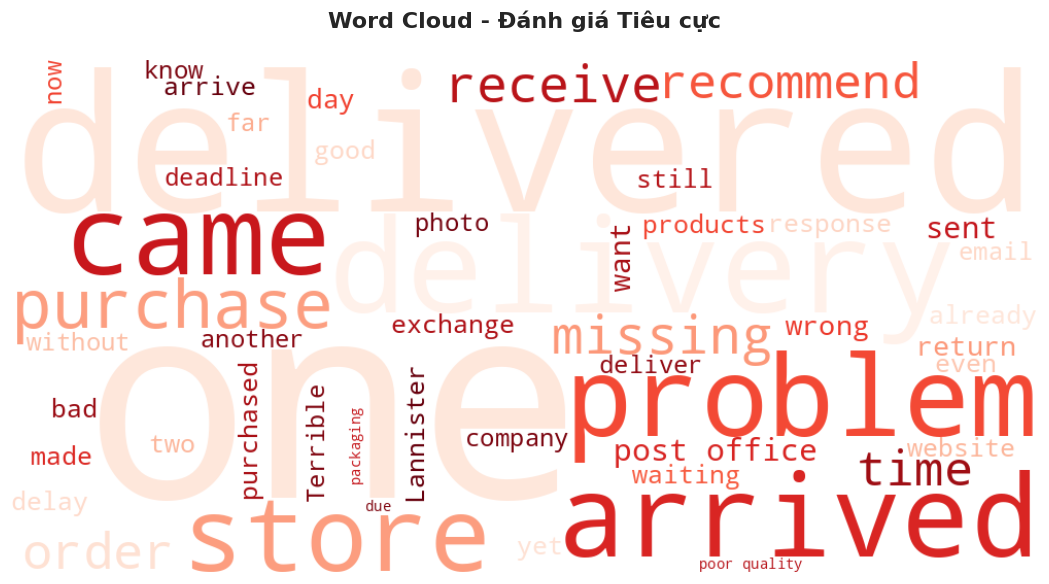

In [ ]:
negative_reviews = df_final[df_final['sentiment_label'] == 'Negative']['review_comment_message_english'].dropna().astype(str)

text_negative = " ".join(review for review in negative_reviews)

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["product", "item", "buy", "bought", "received", "will"])

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=custom_stopwords,
    colormap='Reds',
    max_words=50,
    random_state=42
).generate(text_negative)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Đánh giá Tiêu cực\n', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

##Bar chart xác định lí do có đánh giá tiêu cực

In [ ]:
def identify_factors(text):
    text = text.lower()
    factors = []

    #  Yếu tố Vận chuyển (Delivery/Logistics)
    if any(word in text for word in ['delivery', 'late', 'delay', 'post', 'time', 'arrived', 'receive', 'waiting']):
        factors.append('Vận chuyển & Giao hàng')

    # Yếu tố hàng hoá
    if any(word in text for word in ['wrong', 'missing', 'incomplete', 'different', 'size', 'part']):
        factors.append('Sai hàng / Thiếu hàng')

    # Yếu tố Dịch vụ
    if any(word in text for word in ['return', 'refund', 'answer', 'seller', 'contact', 'message', 'ignore']):
        factors.append('Dịch vụ & Hỗ trợ khách hàng')

    return factors

In [ ]:
df_negatives = df_final[df_final['sentiment_label'] == 'Negative'].copy()
df_negatives['factors'] = df_negatives['review_comment_message_english'].apply(identify_factors)
factors_exploded = df_negatives.explode('factors')
factor_counts = factors_exploded['factors'].value_counts()

/tmp/ipykernel_19835/2063024660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=factor_counts.values, y=factor_counts.index, palette="Reds")


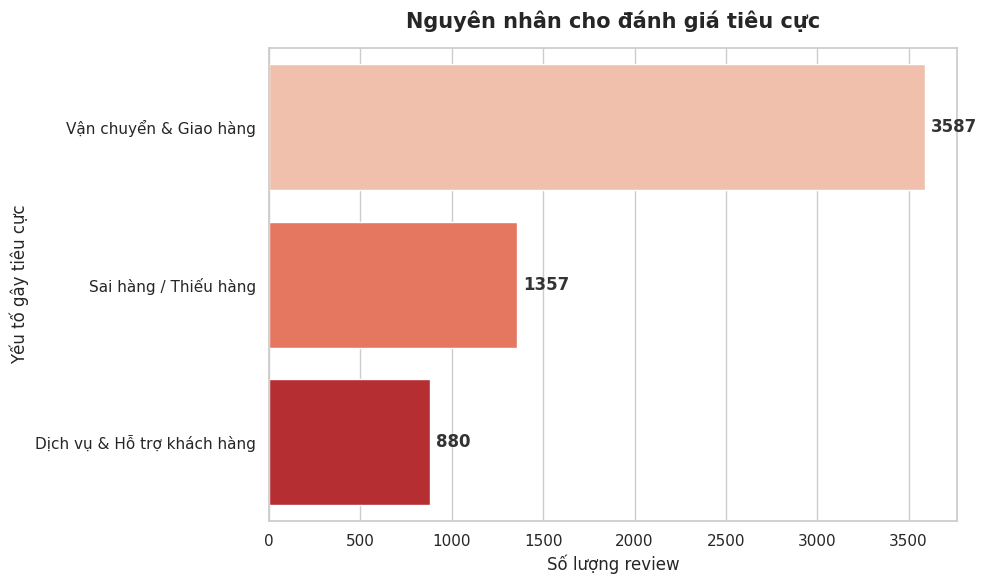

In [ ]:
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

ax = sns.barplot(x=factor_counts.values, y=factor_counts.index, palette="Reds")

plt.title('Nguyên nhân cho đánh giá tiêu cực', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Số lượng review', fontsize=12)
plt.ylabel('Yếu tố gây tiêu cực', fontsize=12)

for i, v in enumerate(factor_counts.values):
    ax.text(v + (max(factor_counts.values)*0.01), i, str(v), va='center', fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

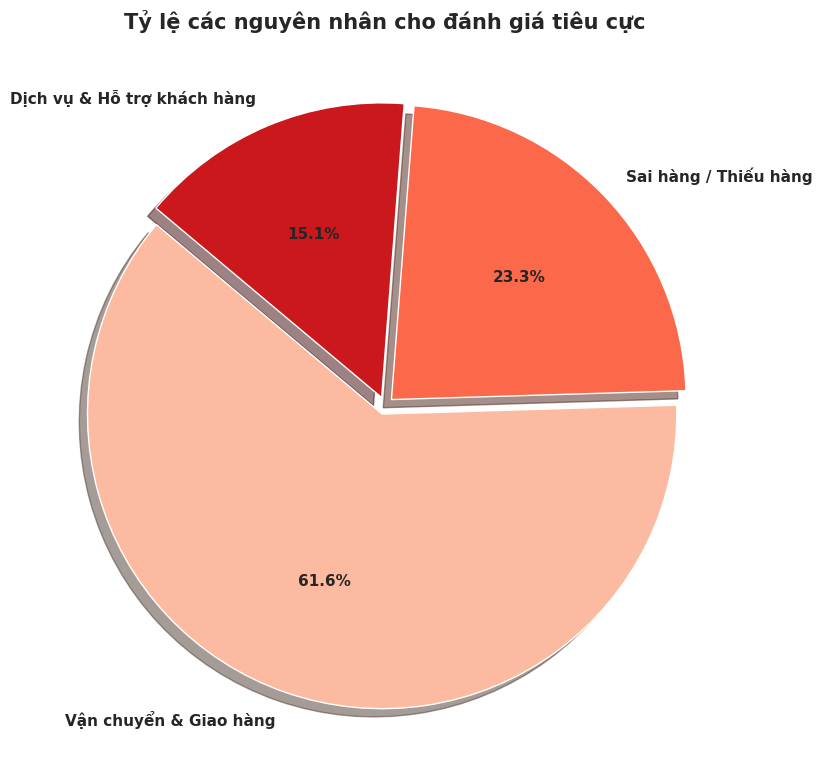

In [ ]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette("Reds", len(factor_counts))

plt.pie(
    factor_counts,
    labels=factor_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.03] * len(factor_counts),
    shadow=True,
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Tỷ lệ các nguyên nhân cho đánh giá tiêu cực', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()